# 1.import libraries

In [5]:
from ast import increment_lineno
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,roc_curve,classification_report
%matplotlib inline
import matplotlib.pyplot as plt
from  sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')


# Problem Statement : Customer Churn Prediction

In [6]:
# Customer id: identifier for each customer.
# Tenure: the duration in years for which the customer has been associated with the ecommerce platform.
# PreferredLoginDevice: The device preferred by the customer for Logging into the ecommerce paltform.
# CityTier:The tier of the city where the customer resides
# WarehouseToHome: Distance in between warehouse to home of customer
# PreferredPaymentmode: The preferred mode of payment chosen by the customer.
# Gender: The gender of the customer
# HourSpend on app: The number of hours the customer spends on the ecommerce platform's mobile appplications.
# Mobile of device Registered: the count of devices registered by the customer.
# Prefered order ca : The preferred category for ordering products.
# SatisfactionScore: The level of satisfaction of the customer with the ecommerce platform's service.
# Marital status: The marital status of the customer.
# The number of address: The number of addresses associated with the customer's account.
# Complain: Indicates wheather the customer has ladged a compliant (1 for yes,0 for  no).
# OrderAmountHike From Last Year: The percentage increase in order amount from the last year.
# CouponUsed: The number of coupon used  by the customer.
# DaySince Last Order: The number of days since the customer 's Last order.
# Cashback Amount : The amount of Cashback received by the customer.
# churn: Indicates whether the customeris going to churn (1 for yes, 0 for no),i.e..,
# whether the customer will stop using the ecommerce platform.

# 2. load dataset

In [7]:
from google.colab import files
files.upload()

Saving E Commerce Dataset.xlsx to E Commerce Dataset (1).xlsx


{'E Commerce Dataset (1).xlsx': b'PK\x03\x04\x14\x00\x06\x00\x08\x00\x00\x00!\x00b\xee\x9dh^\x01\x00\x00\x90\x04\x00\x00\x13\x00\x08\x02[Content_Types].xml \xa2\x04\x02(\xa0\x00\x02\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x0

In [10]:
df = pd.read_excel('E Commerce Dataset.xlsx')

In [11]:
df.head(50)

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60
5,50006,1,0.0,Computer,1,22.0,Debit Card,Female,3.0,5,Mobile Phone,5,Single,2,1,22.0,4.0,6.0,7.0,139.19
6,50007,1,NaN,Phone,3,11.0,Cash on Delivery,Male,2.0,3,Laptop & Accessory,2,Divorced,4,0,14.0,0.0,1.0,0.0,120.86
7,50008,1,NaN,Phone,1,6.0,CC,Male,3.0,3,Mobile,2,Divorced,3,1,16.0,2.0,2.0,0.0,122.93
8,50009,1,13.0,Phone,3,9.0,E wallet,Male,NaN,4,Mobile,3,Divorced,2,1,14.0,0.0,1.0,2.0,126.83
9,50010,1,NaN,Phone,1,31.0,Debit Card,Male,2.0,5,Mobile,3,Single,2,0,12.0,1.0,1.0,1.0,122.93


In [12]:
# first five rows of the dataset

In [13]:
df.head(5)

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [14]:
# last five rows of the dataset

In [15]:
df.tail()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
5625,55626,0,10.0,Computer,1,30.0,Credit Card,Male,3.0,2,Laptop & Accessory,1,Married,6,0,18.0,1.0,2.0,4.0,150.71
5626,55627,0,13.0,Mobile Phone,1,13.0,Credit Card,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,2.0,NaN,224.91
5627,55628,0,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,2.0,4.0,186.42
5628,55629,0,23.0,Computer,3,9.0,Credit Card,Male,4.0,5,Laptop & Accessory,4,Married,4,0,15.0,2.0,2.0,9.0,178.90
5629,55630,0,8.0,Mobile Phone,1,15.0,Credit Card,Male,3.0,2,Laptop & Accessory,3,Married,4,0,13.0,2.0,2.0,3.0,169.04


# 3.EDA - Read and explore the data

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [17]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


In [18]:
df.isna().sum()

,0
CustomerID,0
Churn,0
Tenure,264
PreferredLoginDevice,0
CityTier,0
WarehouseToHome,251
PreferredPaymentMode,0
Gender,0
HourSpendOnApp,255
NumberOfDeviceRegistered,0


In [19]:
df.isna().sum()*100/len(df)

,0
CustomerID,0.000000
Churn,0.000000
Tenure,4.689165
PreferredLoginDevice,0.000000
CityTier,0.000000
WarehouseToHome,4.458259
PreferredPaymentMode,0.000000
Gender,0.000000
HourSpendOnApp,4.529307
NumberOfDeviceRegistered,0.000000


# null value imputation

In [20]:
df.columns

Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

In [21]:
numerical_columns = ['Tenure','WarehouseToHome','HourSpendOnApp','OrderAmountHikeFromlastYear','CouponUsed','OrderCount','DaySinceLastOrder']
for column in list(numerical_columns):
  df[column].fillna(df[column].median(),inplace = True)

In [22]:
df.isna().sum()*100/len(df)

,0
CustomerID,0.0
Churn,0.0
Tenure,0.0
PreferredLoginDevice,0.0
CityTier,0.0
WarehouseToHome,0.0
PreferredPaymentMode,0.0
Gender,0.0
HourSpendOnApp,0.0
NumberOfDeviceRegistered,0.0


In [23]:
for col in df.columns:
  print(col)
  print(df[col].unique())
  print("")

CustomerID
[50001 50002 50003 ... 55628 55629 55630]

Churn
[1 0]

Tenure
[ 4.  9.  0. 13. 11. 19. 20. 14.  8. 18.  5.  2. 30.  1. 23.  3. 29.  6.
 26. 28.  7. 24. 25. 10. 15. 22. 27. 16. 12. 21. 17. 50. 60. 31. 51. 61.]

PreferredLoginDevice
['Mobile Phone' 'Phone' 'Computer']

CityTier
[3 1 2]

WarehouseToHome
[  6.   8.  30.  15.  12.  22.  11.   9.  31.  18.  13.  20.  29.  28.
  26.  14.  10.  27.  17.  23.  33.  19.  35.  24.  16.  25.  32.  34.
   5.  21. 126.   7.  36. 127.]

PreferredPaymentMode
['Debit Card' 'UPI' 'CC' 'Cash on Delivery' 'E wallet' 'COD' 'Credit Card']

Gender
['Female' 'Male']

HourSpendOnApp
[3. 2. 1. 0. 4. 5.]

NumberOfDeviceRegistered
[3 4 5 2 1 6]

PreferedOrderCat
['Laptop & Accessory' 'Mobile' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']

SatisfactionScore
[2 3 5 4 1]

MaritalStatus
['Single' 'Divorced' 'Married']

NumberOfAddress
[ 9  7  6  8  3  2  4 10  1  5 19 21 11 20 22]

Complain
[1 0]

OrderAmountHikeFromlastYear
[11. 15. 14. 23. 22. 16. 12. 13

In [24]:
df['PreferredLoginDevice'].value_counts()

,count
PreferredLoginDevice,
Mobile Phone,2765
Computer,1634
Phone,1231


In [25]:
##### As mobile phones and phones are same,Let's merge them.


In [26]:
category_mapping = {'Phone':'Mobile Phone'}
df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace(category_mapping)
print(df['PreferredLoginDevice'].value_counts())

PreferredLoginDevice
Mobile Phone    3996
Computer        1634
Name: count, dtype: int64


In [27]:
df.replace({"PreferredLoginDevice": {'Mobile Phone': 0 , 'Computer': 1}}, inplace=True)

In [28]:
df['PreferredLoginDevice']

,PreferredLoginDevice
0,0
1,0
2,0
3,0
4,0
...,...
5625,1
5626,0
5627,0
5628,1


In [29]:
df['PreferredPaymentMode'].value_counts()

,count
PreferredPaymentMode,
Debit Card,2314
Credit Card,1501
E wallet,614
UPI,414
COD,365
CC,273
Cash on Delivery,149


In [30]:
#  As Credit card and CC are same, Lets merge them,
# As COD and Cash on Delivery are same, Lets merge them,

In [31]:
category_mapping = {'CC':'Credit Card','Cash on Delivery':'COD'}
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace(category_mapping)
print(df['PreferredPaymentMode'].value_counts())

PreferredPaymentMode
Debit Card     2314
Credit Card    1774
E wallet        614
COD             514
UPI             414
Name: count, dtype: int64


In [32]:
df['Gender'].value_counts()

,count
Gender,
Male,3384
Female,2246


In [33]:
df.replace({'Gender': {'Male':0,'Female':1}},inplace=True)

In [34]:
df['Gender']

,Gender
0,1
1,0
2,0
3,0
4,0
...,...
5625,0
5626,0
5627,0
5628,0


In [35]:
df['PreferedOrderCat'].value_counts()

,count
PreferedOrderCat,
Laptop & Accessory,2050
Mobile Phone,1271
Fashion,826
Mobile,809
Grocery,410
Others,264


In [36]:
category_mapping = {'Mobile':'Mobile Phone'}
df['PreferedOrderCat'] = df['PreferedOrderCat'].replace(category_mapping)
print(df['PreferedOrderCat'].value_counts())

PreferedOrderCat
Mobile Phone          2080
Laptop & Accessory    2050
Fashion                826
Grocery                410
Others                 264
Name: count, dtype: int64


In [37]:
df['MaritalStatus'].value_counts()

,count
MaritalStatus,
Married,2986
Single,1796
Divorced,848


In [38]:
df['Churn'].value_counts()

,count
Churn,
0,4682
1,948


In [39]:
# visualizing numerical variables

In [40]:
# box plots

<Axes: xlabel='Churn', ylabel='CashbackAmount'>

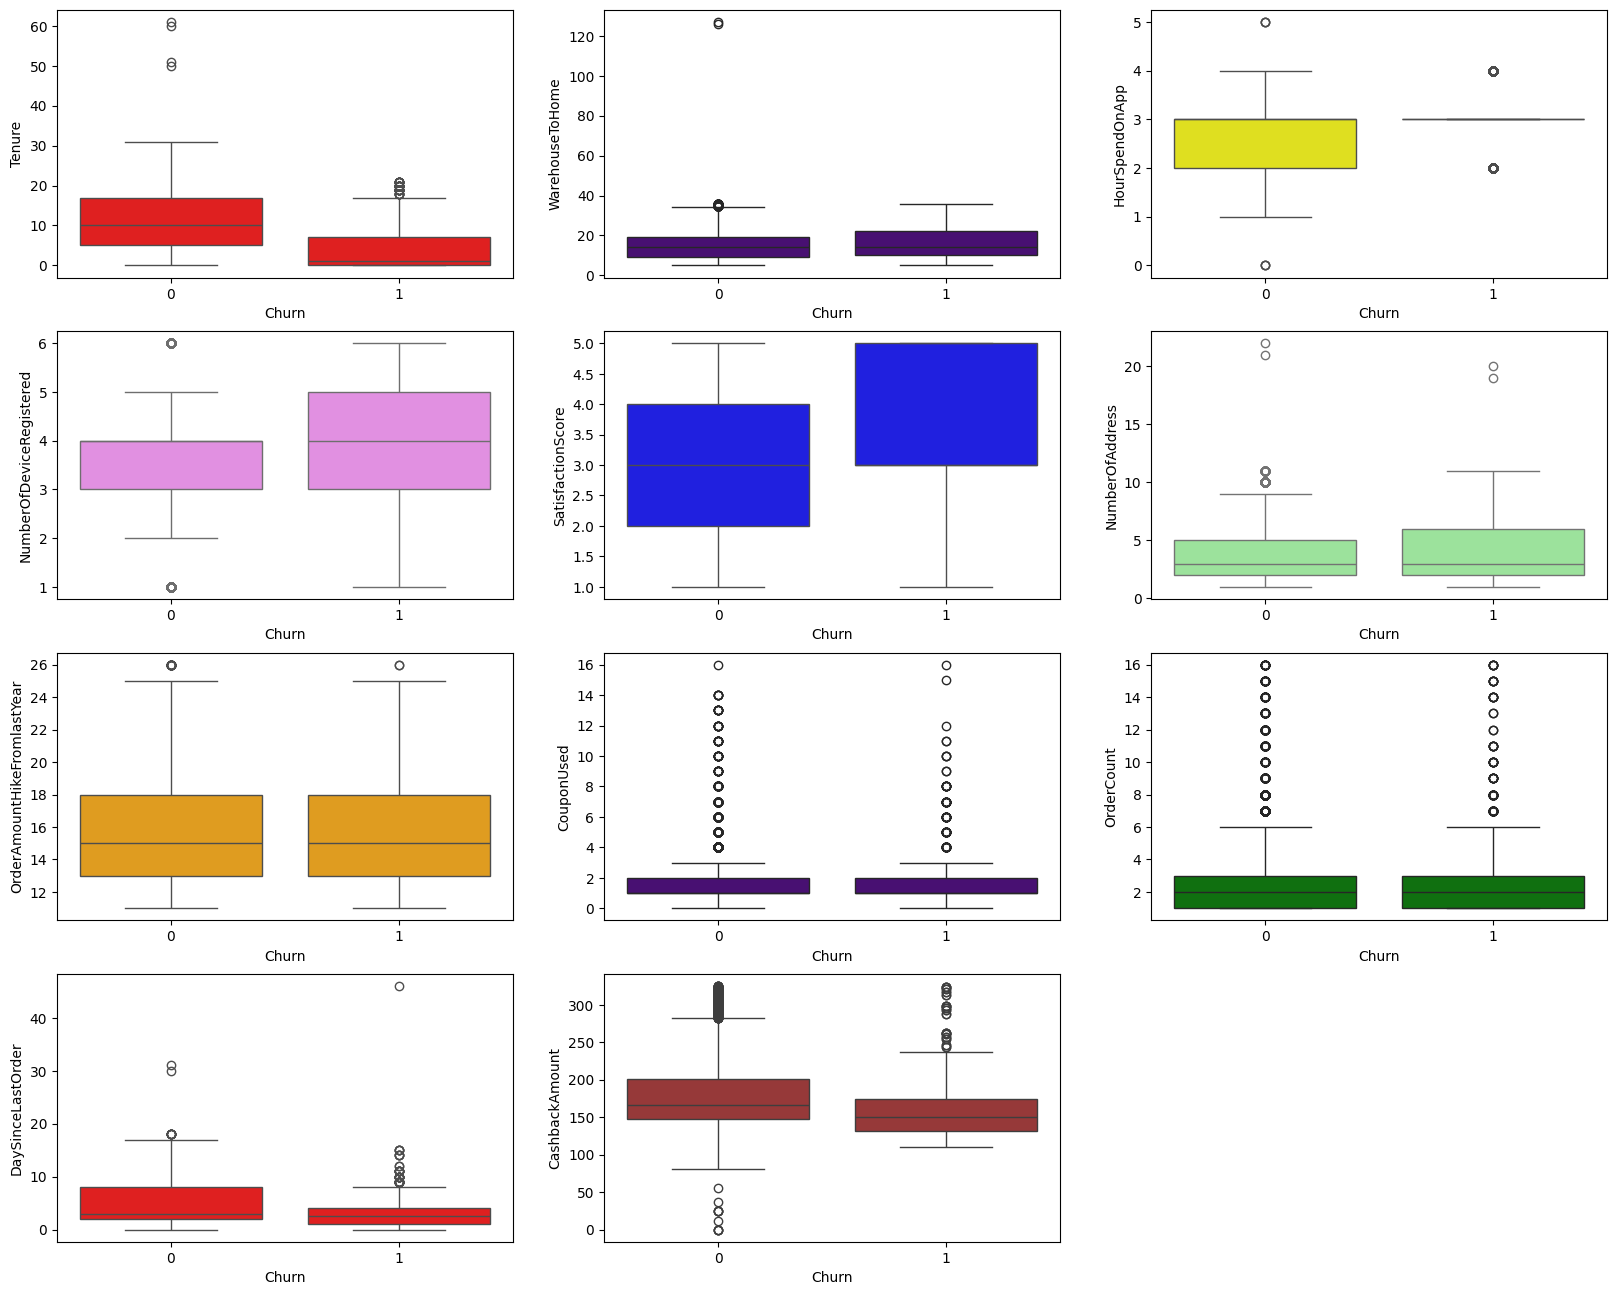

In [41]:
plt.figure(figsize=(20,16))
plt.subplot(4,3,1)
sns.boxplot(x='Churn',y='Tenure',color='red',data=df)
plt.subplot(4,3,2)
sns.boxplot(x = 'Churn',y='WarehouseToHome',color='indigo',data=df)
plt.subplot(4,3,3)
sns.boxplot(x='Churn',y='HourSpendOnApp',color='yellow',data=df)
plt.subplot(4,3,4)
sns.boxplot(x = 'Churn',y='NumberOfDeviceRegistered',color='violet',data=df)
plt.subplot(4,3,5)
sns.boxplot(x='Churn',y='SatisfactionScore',data=df,color='blue')
plt.subplot(4,3,6)
sns.boxplot(x='Churn',y='NumberOfAddress',data=df,color='lightgreen')
plt.subplot(4,3,7)
sns.boxplot(x='Churn',y='OrderAmountHikeFromlastYear',data=df,color='orange')
plt.subplot(4,3,8)
sns.boxplot(x='Churn',y='CouponUsed',data=df,color='indigo')
plt.subplot(4,3,9)
sns.boxplot(x='Churn',y='OrderCount',data=df,color='green')
plt.subplot(4,3,10)
sns.boxplot(x='Churn',y='DaySinceLastOrder',data=df,color='red')
plt.subplot(4,3,11)
sns.boxplot(x='Churn',y='CashbackAmount',data=df,color='brown')







In [42]:
df.columns

Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

# 4. split train and test data

In [43]:
X = df.drop('Churn',axis=1)
y = df['Churn']

In [44]:
X

,CustomerID,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,4.0,0,3,6.0,Debit Card,1,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,9.0,0,1,8.0,UPI,0,3.0,4,Mobile Phone,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,9.0,0,1,30.0,Debit Card,0,2.0,4,Mobile Phone,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,0.0,0,3,15.0,Debit Card,0,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,0.0,0,1,12.0,Credit Card,0,3.0,3,Mobile Phone,5,Single,3,0,11.0,1.0,1.0,3.0,129.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,55626,10.0,1,1,30.0,Credit Card,0,3.0,2,Laptop & Accessory,1,Married,6,0,18.0,1.0,2.0,4.0,150.71
5626,55627,13.0,0,1,13.0,Credit Card,0,3.0,5,Fashion,5,Married,6,0,16.0,1.0,2.0,3.0,224.91
5627,55628,1.0,0,1,11.0,Debit Card,0,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,2.0,4.0,186.42
5628,55629,23.0,1,3,9.0,Credit Card,0,4.0,5,Laptop & Accessory,4,Married,4,0,15.0,2.0,2.0,9.0,178.90


In [45]:
y

,Churn
0,1
1,1
2,1
3,1
4,1
...,...
5625,0
5626,0
5627,0
5628,0


In [46]:
import pandas as pd
categorical_features = ['PreferredPaymentMode','PreferedOrderCat','MaritalStatus']
X = pd.get_dummies(X,columns=categorical_features,dtype=int)



In [47]:
X

,CustomerID,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,Gender,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,...,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,PreferedOrderCat_Fashion,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,50001,4.0,0,3,6.0,1,3.0,3,2,9,...,0,0,0,0,1,0,0,0,0,1
1,50002,9.0,0,1,8.0,0,3.0,4,3,7,...,0,1,0,0,0,1,0,0,0,1
2,50003,9.0,0,1,30.0,0,2.0,4,3,6,...,0,0,0,0,0,1,0,0,0,1
3,50004,0.0,0,3,15.0,0,2.0,4,5,8,...,0,0,0,0,1,0,0,0,0,1
4,50005,0.0,0,1,12.0,0,3.0,3,5,3,...,0,0,0,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,55626,10.0,1,1,30.0,0,3.0,2,1,6,...,0,0,0,0,1,0,0,0,1,0
5626,55627,13.0,0,1,13.0,0,3.0,5,5,6,...,0,0,1,0,0,0,0,0,1,0
5627,55628,1.0,0,1,11.0,0,3.0,2,4,3,...,0,0,0,0,1,0,0,0,1,0
5628,55629,23.0,1,3,9.0,0,4.0,5,4,4,...,0,0,0,0,1,0,0,0,1,0


In [48]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [49]:
df.shape

(5630, 20)

In [50]:
X_train.shape


(4504, 29)

In [51]:
y_train.shape

(4504,)

In [52]:
X_test.shape

(1126, 29)

In [53]:
y_test.shape

(1126,)

# 5.Fit and Evaluate model

In [54]:
def fit_and_evaluate_model(X_train,X_test,y_train,y_test,max_depth=5,min_samples_split=0.01,
                           max_features=0.8,max_samples=0.8):
  random_forest = RandomForestClassifier(random_state=0,\
                                         max_depth=max_depth,\
                                         min_samples_split=min_samples_split,\
                                         max_features=max_features,
                                         max_samples=max_samples)
  model=random_forest.fit(X_train,y_train)
  random_forest_predict = random_forest.predict(X_test)
  random_forest_conf_matrix = confusion_matrix(y_test,random_forest_predict)
  random_forest_acc_score = accuracy_score(y_test,random_forest_predict)
  print("Confusion_Matrix")
  print(random_forest_conf_matrix)
  print("\n")
  print("Accuracy of Random Forest:",random_forest_acc_score*100,'\n')
  print(classification_report(y_test,random_forest_predict))
  return model

In [55]:
model = fit_and_evaluate_model(X_train,X_test,y_train,y_test)

Confusion_Matrix
[[915  26]
 [ 84 101]]


Accuracy of Random Forest: 90.23090586145648 

              precision    recall  f1-score   support

           0       0.92      0.97      0.94       941
           1       0.80      0.55      0.65       185

    accuracy                           0.90      1126
   macro avg       0.86      0.76      0.80      1126
weighted avg       0.90      0.90      0.89      1126



#  6.Try different parameters to identify best ones

In [56]:
param_grid = [
    {'max_depth':[3,5,7,10],'min_samples_split':[0.01,0.03,0.07,0.1],
     'max_features':[0.7,0.8,0.9,1.0],
     'max_samples':[0.7,0.8,0.9,1.0]}]


In [57]:
from sklearn.model_selection import GridSearchCV
model = RandomForestClassifier()
search = GridSearchCV(estimator=model,param_grid=param_grid,cv=5,verbose=5)
search.fit(X_train,y_train)


Fitting 5 folds for each of 256 candidates, totalling 1280 fits
[CV 1/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.868 total time=   0.5s
[CV 2/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.873 total time=   0.5s
[CV 3/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.878 total time=   0.6s
[CV 4/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.883 total time=   0.6s
[CV 5/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.880 total time=   0.5s
[CV 1/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.03;, score=0.868 total time=   0.6s
[CV 2/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.03;, score=0.873 total time=   0.5s
[CV 3/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.03;, score=0.887 total time=   0.5s


GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid=[{'max_depth': [3, 5, 7, 10],
                          'max_features': [0.7, 0.8, 0.9, 1.0],
                          'max_samples': [0.7, 0.8, 0.9, 1.0],
                          'min_samples_split': [0.01, 0.03, 0.07, 0.1]}],
             verbose=5)

In [58]:
results = pd.DataFrame(search.cv_results_)
results.sort_values('mean_test_score',inplace=True,ascending=False)
results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,param_max_samples,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
220,1.653663,0.227832,0.020457,0.001778,10,0.8,1.0,0.01,"{'max_depth': 10, 'max_features': 0.8, 'max_sa...",0.901221,0.901221,0.903441,0.916759,0.915556,0.907639,0.007012,1
200,1.220339,0.009954,0.017542,0.000615,10,0.7,0.9,0.01,"{'max_depth': 10, 'max_features': 0.7, 'max_sa...",0.901221,0.896781,0.899001,0.923418,0.914444,0.906973,0.010264,2
252,1.992335,0.240894,0.018828,0.002712,10,1.0,1.0,0.01,"{'max_depth': 10, 'max_features': 1.0, 'max_sa...",0.902331,0.892342,0.902331,0.915649,0.918889,0.906308,0.009718,3
204,1.311820,0.021901,0.017341,0.000776,10,0.7,1.0,0.01,"{'max_depth': 10, 'max_features': 0.7, 'max_sa...",0.897891,0.897891,0.904550,0.920089,0.911111,0.906307,0.008459,4
216,1.566025,0.213876,0.021584,0.004375,10,0.8,0.9,0.01,"{'max_depth': 10, 'max_features': 0.8, 'max_sa...",0.895671,0.892342,0.901221,0.921199,0.915556,0.905198,0.011271,5
236,1.627075,0.016460,0.017022,0.000782,10,0.9,1.0,0.01,"{'max_depth': 10, 'max_features': 0.9, 'max_sa...",0.899001,0.892342,0.899001,0.913430,0.918889,0.904532,0.009951,6
196,1.331120,0.216944,0.018818,0.002249,10,0.7,0.8,0.01,"{'max_depth': 10, 'max_features': 0.7, 'max_sa...",0.901221,0.893452,0.899001,0.917869,0.910000,0.904309,0.008624,7
232,1.713346,0.207534,0.020687,0.003313,10,0.9,0.9,0.01,"{'max_depth': 10, 'max_features': 0.9, 'max_sa...",0.900111,0.895671,0.901221,0.907880,0.912222,0.903421,0.005886,8
140,1.229579,0.177046,0.017850,0.002665,7,0.7,1.0,0.01,"{'max_depth': 7, 'max_features': 0.7, 'max_sam...",0.897891,0.890122,0.903441,0.918979,0.905556,0.903198,0.009527,9
248,1.879562,0.242968,0.019437,0.003250,10,1.0,0.9,0.01,"{'max_depth': 10, 'max_features': 1.0, 'max_sa...",0.894562,0.894562,0.903441,0.908990,0.913333,0.902977,0.007553,10


In [59]:
results_save = pd.DataFrame(search.cv_results_)
results_save.to_csv('results_save.csv',index=False)

In [60]:
search.best_params_

{'max_depth': 10,
 'max_features': 0.8,
 'max_samples': 1.0,
 'min_samples_split': 0.01}

# 6. Evaluate the model with best parameters

In [61]:
model = fit_and_evaluate_model(X_train,X_test,y_train,y_test,max_depth=10,min_samples_split=0.01,\
                               max_features=0.8,max_samples=1.0)

Confusion_Matrix
[[916  25]
 [ 65 120]]


Accuracy of Random Forest: 92.00710479573712 

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       941
           1       0.83      0.65      0.73       185

    accuracy                           0.92      1126
   macro avg       0.88      0.81      0.84      1126
weighted avg       0.92      0.92      0.92      1126

